# Student Focus Monitor — ML Pipeline (v2: DAiSEE + Fatigue dataset)

**Pipeline:** DAiSEE + Fatigue dataset → label mapping (Focused / Fatigue / Anxiety / Boredom) → MediaPipe feature extraction → class balancing (SMOTE) → train & compare XGBoost / Random Forest / SVM → evaluation.

**Folder layout expected** (notebook sits at the project root, sibling to `backend/`):

```
Smart-Uni-Guide/
├── student_focus_monitor_pipeline.ipynb   <- this file
└── backend/
    └── datasets/focus/
        ├── DAiSEE/
        │   ├── DataSet/
        │   └── Labels/
        └── fatigue/
            ├── train/{alert,non_vigilant,tired}/*.jpg
            ├── val/{alert,non_vigilant,tired}/*.jpg
            └── test/{alert,non_vigilant,tired}/*.jpg
```

If mediapipe raises `AttributeError: module 'mediapipe' has no attribute 'solutions'`, reinstall with:
```
pip install "mediapipe==0.10.14" --no-cache-dir --force-reinstall
pip install "protobuf>=4.25.3,<5" --no-cache-dir --force-reinstall
```
then **restart the kernel** before re-running.


## 0. Install & import libraries

In [1]:
# Run once. If a package is already installed, pip will just say "already satisfied".
!pip install mediapipe opencv-python xgboost scikit-learn imbalanced-learn pandas numpy matplotlib seaborn tqdm joblib -q



[notice] A new release of pip is available: 26.1.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import os
import glob
import cv2
import numpy as np
import pandas as pd
import mediapipe as mp
from tqdm import tqdm
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from imblearn.over_sampling import SMOTE
from xgboost import XGBClassifier
import joblib

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)


## 1. Config — update these paths to match your project structure

In [3]:
# ==== EDIT THESE PATHS IF YOUR STRUCTURE DIFFERS ====
DAISEE_ROOT = "./backend/datasets/focus/DAiSEE"
LABELS_DIR = os.path.join(DAISEE_ROOT, "Labels")
VIDEOS_DIR = os.path.join(DAISEE_ROOT, "DataSet")

FATIGUE_ROOT = "./backend/datasets/focus/fatigue"
FATIGUE_CLASS_MAP = {"tired": "Fatigue", "non_vigilant": "Fatigue"}  # 'alert' is skipped (driving-context, not studying-context)

FEATURES_CSV = "./features.csv"
FRAME_SAMPLE_RATE = 5            # analyze every Nth frame of each DAiSEE video
MAX_FRAMES_PER_VIDEO = 60        # cap frames per clip so extraction stays fast

MODEL_DIR = "./backend/models/focus"
os.makedirs(MODEL_DIR, exist_ok=True)


## 2. Label mapping — DAiSEE (Boredom / Engagement / Confusion / Frustration, each 0–3) → your 4 states

| Your class | Rule (DAiSEE's 0–3 scores) | Justification |
|---|---|---|
| **Focused** | Engagement ≥ 2 AND Boredom ≤ 1 AND Confusion ≤ 1 AND Frustration ≤ 1 | High engagement with low negative affect |
| **Boredom** | Boredom ≥ 2 | Direct match — DAiSEE has this label |
| **Anxiety** | Frustration ≥ 2 OR Confusion ≥ 2 (and Boredom ≤ 1) | Closest available proxy |
| **Fatigue** | Engagement ≤ 1 AND Boredom ≤ 1 AND Confusion ≤ 1 AND Frustration ≤ 1 | Weak DAiSEE proxy — reinforced below with a dedicated Fatigue dataset |

Rows that don't cleanly satisfy any rule are dropped.


In [4]:
def load_daisee_labels():
    dfs = []
    for split, fname in [("Train", "TrainLabels.csv"),
                          ("Validation", "ValidationLabels.csv"),
                          ("Test", "TestLabels.csv")]:
        path = os.path.join(LABELS_DIR, fname)
        d = pd.read_csv(path)
        d.columns = [c.strip() for c in d.columns]
        d["split"] = split
        dfs.append(d)
    labels = pd.concat(dfs, ignore_index=True)
    labels["ClipID"] = labels["ClipID"].astype(str).str.strip()
    return labels


def map_to_target_class(row):
    b, e, c, f = row["Boredom"], row["Engagement"], row["Confusion"], row["Frustration"]
    if e >= 2 and b <= 1 and c <= 1 and f <= 1:
        return "Focused"
    if b >= 2:
        return "Boredom"
    if (f >= 2 or c >= 2) and b <= 1:
        return "Anxiety"
    if e <= 1 and b <= 1 and c <= 1 and f <= 1:
        return "Fatigue"
    return None  # ambiguous row -> dropped


labels_df = load_daisee_labels()
labels_df["target_class"] = labels_df.apply(map_to_target_class, axis=1)
labels_df = labels_df.dropna(subset=["target_class"]).reset_index(drop=True)

print("Rows kept after mapping:", len(labels_df))
print(labels_df["target_class"].value_counts())


Rows kept after mapping: 8571
target_class
Focused    5647
Boredom    2213
Anxiety     591
Fatigue     120
Name: count, dtype: int64


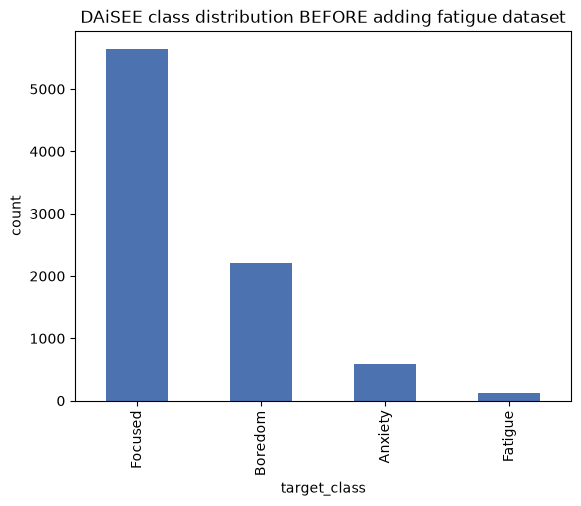

In [5]:
labels_df["target_class"].value_counts().plot(kind="bar", color="#4C72B0")
plt.title("DAiSEE class distribution BEFORE adding fatigue dataset")
plt.ylabel("count")
plt.show()


## 3. Feature extraction with MediaPipe (shared helper functions)

Used for both DAiSEE videos (Section 4) and the fatigue dataset images (Section 5).


In [6]:
mp_face_mesh = mp.solutions.face_mesh

LEFT_EYE = [362, 385, 387, 263, 373, 380]
RIGHT_EYE = [33, 160, 158, 133, 153, 144]
MOUTH = [61, 291, 39, 181, 0, 17]

MODEL_3D_POINTS = np.array([
    (0.0, 0.0, 0.0), (0.0, -63.6, -12.5),
    (-43.3, 32.7, -26.0), (43.3, 32.7, -26.0),
    (-28.9, -28.9, -24.1), (28.9, -28.9, -24.1),
], dtype=np.float64)
POSE_LANDMARK_IDS = [1, 152, 33, 263, 61, 291]


def _dist(p1, p2):
    return np.linalg.norm(np.array(p1) - np.array(p2))


def eye_aspect_ratio(landmarks, eye_idx, w, h):
    pts = [(landmarks[i].x * w, landmarks[i].y * h) for i in eye_idx]
    vertical = _dist(pts[1], pts[5]) + _dist(pts[2], pts[4])
    horizontal = _dist(pts[0], pts[3])
    return vertical / (2.0 * horizontal + 1e-6)


def mouth_aspect_ratio(landmarks, w, h):
    pts = [(landmarks[i].x * w, landmarks[i].y * h) for i in MOUTH]
    vertical = _dist(pts[2], pts[3]) + _dist(pts[4], pts[5])
    horizontal = _dist(pts[0], pts[1])
    return vertical / (2.0 * horizontal + 1e-6)


def head_pose_angles(landmarks, w, h):
    img_points = np.array(
        [(landmarks[i].x * w, landmarks[i].y * h) for i in POSE_LANDMARK_IDS],
        dtype=np.float64,
    )
    focal_length = w
    center = (w / 2, h / 2)
    camera_matrix = np.array(
        [[focal_length, 0, center[0]], [0, focal_length, center[1]], [0, 0, 1]],
        dtype=np.float64,
    )
    dist_coeffs = np.zeros((4, 1))
    success, rvec, tvec = cv2.solvePnP(
        MODEL_3D_POINTS, img_points, camera_matrix, dist_coeffs
    )
    if not success:
        return 0.0, 0.0, 0.0
    rmat, _ = cv2.Rodrigues(rvec)
    sy = np.sqrt(rmat[0, 0] ** 2 + rmat[1, 0] ** 2)
    pitch = np.degrees(np.arctan2(-rmat[2, 0], sy))
    yaw = np.degrees(np.arctan2(rmat[1, 0], rmat[0, 0]))
    roll = np.degrees(np.arctan2(rmat[2, 1], rmat[2, 2]))
    return pitch, yaw, roll


def process_video(video_path, blink_ear_thresh=0.21, yawn_mar_thresh=0.6):
    cap = cv2.VideoCapture(video_path)
    ears, mars, pitches, yaws, rolls = [], [], [], [], []
    blink_frames, yawn_frames, frame_count, analyzed = 0, 0, 0, 0

    with mp_face_mesh.FaceMesh(
        static_image_mode=False, max_num_faces=1, refine_landmarks=True,
        min_detection_confidence=0.5, min_tracking_confidence=0.5,
    ) as face_mesh:
        while cap.isOpened() and analyzed < MAX_FRAMES_PER_VIDEO:
            ret, frame = cap.read()
            if not ret:
                break
            frame_count += 1
            if frame_count % FRAME_SAMPLE_RATE != 0:
                continue
            h, w = frame.shape[:2]
            rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
            result = face_mesh.process(rgb)
            if not result.multi_face_landmarks:
                continue
            lm = result.multi_face_landmarks[0].landmark

            ear = (eye_aspect_ratio(lm, LEFT_EYE, w, h) + eye_aspect_ratio(lm, RIGHT_EYE, w, h)) / 2.0
            mar = mouth_aspect_ratio(lm, w, h)
            pitch, yaw, roll = head_pose_angles(lm, w, h)

            ears.append(ear); mars.append(mar)
            pitches.append(pitch); yaws.append(yaw); rolls.append(roll)
            if ear < blink_ear_thresh:
                blink_frames += 1
            if mar > yawn_mar_thresh:
                yawn_frames += 1
            analyzed += 1
    cap.release()

    if analyzed == 0:
        return None

    return {
        "ear_mean": np.mean(ears), "ear_std": np.std(ears),
        "mar_mean": np.mean(mars), "mar_std": np.std(mars),
        "blink_rate": blink_frames / analyzed,
        "yawn_rate": yawn_frames / analyzed,
        "pitch_mean": np.mean(pitches), "pitch_std": np.std(pitches),
        "yaw_mean": np.mean(yaws), "yaw_std": np.std(yaws),
        "roll_mean": np.mean(rolls), "roll_std": np.std(rolls),
        "frames_analyzed": analyzed,
    }


def process_image(image_path, blink_ear_thresh=0.21, yawn_mar_thresh=0.6):
    frame = cv2.imread(image_path)
    if frame is None:
        return None
    h, w = frame.shape[:2]
    rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
    with mp_face_mesh.FaceMesh(
        static_image_mode=True, max_num_faces=1, refine_landmarks=True,
        min_detection_confidence=0.5,
    ) as face_mesh:
        result = face_mesh.process(rgb)
    if not result.multi_face_landmarks:
        return None
    lm = result.multi_face_landmarks[0].landmark
    ear = (eye_aspect_ratio(lm, LEFT_EYE, w, h) + eye_aspect_ratio(lm, RIGHT_EYE, w, h)) / 2.0
    mar = mouth_aspect_ratio(lm, w, h)
    pitch, yaw, roll = head_pose_angles(lm, w, h)
    return {
        "ear": ear, "mar": mar, "pitch": pitch, "yaw": yaw, "roll": roll,
        "blink": ear < blink_ear_thresh, "yawn": mar > yawn_mar_thresh,
    }


## 4. Extract features from every DAiSEE video

In [7]:
def find_video_path(clip_id, split):
    pattern = os.path.join(VIDEOS_DIR, split, "**", f"{clip_id}*")
    matches = glob.glob(pattern, recursive=True)
    matches = [m for m in matches if m.lower().endswith((".avi", ".mp4"))]
    return matches[0] if matches else None


rows = []
for _, row in tqdm(labels_df.iterrows(), total=len(labels_df), desc="Extracting DAiSEE features"):
    vpath = find_video_path(row["ClipID"], row["split"])
    if vpath is None:
        continue
    feats = process_video(vpath)
    if feats is None:
        continue
    feats["ClipID"] = row["ClipID"]
    feats["target_class"] = row["target_class"]
    rows.append(feats)

features_df = pd.DataFrame(rows)
features_df.to_csv(FEATURES_CSV, index=False)
print("Saved", len(features_df), "DAiSEE feature rows to", FEATURES_CSV)
features_df.head()


Extracting DAiSEE features:   0%|          | 0/8571 [00:00<?, ?it/s]C:\Users\CNN COMPUTERS\AppData\Roaming\Python\Python311\site-packages\google\protobuf\symbol_database.py:55: UserWarning: SymbolDatabase.GetPrototype() is deprecated. Please use message_factory.GetMessageClass() instead. SymbolDatabase.GetPrototype() will be removed soon.
  warnings.warn('SymbolDatabase.GetPrototype() is deprecated. Please '
Extracting DAiSEE features: 100%|██████████| 8571/8571 [3:27:56<00:00,  1.46s/it]  


Saved 8570 DAiSEE feature rows to ./features.csv


,ear_mean,ear_std,mar_mean,mar_std,blink_rate,yawn_rate,pitch_mean,pitch_std,yaw_mean,yaw_std,roll_mean,roll_std,frames_analyzed,ClipID,target_class
0,0.242122,0.032010,0.431089,0.062768,0.050000,0.0,1.133813,9.317401,1.684972,6.588016,167.083213,2.026429,60,1100011002.avi,Focused
1,0.257726,0.025694,0.456768,0.034258,0.016667,0.0,7.784650,6.445147,-4.239646,3.455273,167.987944,1.947678,60,1100011003.avi,Focused
2,0.255284,0.011850,0.474106,0.026786,0.016667,0.0,9.513453,6.976646,-4.533052,3.844823,167.952284,1.922725,60,1100011004.avi,Focused
3,0.258086,0.015604,0.498047,0.024805,0.033333,0.0,0.277054,8.746631,-0.573600,3.281762,168.567080,1.998028,60,1100011005.avi,Focused
4,0.232804,0.027062,0.429164,0.038014,0.150000,0.0,0.063224,7.645358,6.708000,22.494944,162.060001,42.494245,60,1100011006.avi,Focused


## 5. Add the Fatigue dataset (fixes DAiSEE's weak Fatigue proxy)

Images are grouped by subject ID (parsed from filenames like `1003_frame16.jpg`) and aggregated the same way as a DAiSEE video clip, so the resulting rows have the exact same feature columns and can be merged directly.


In [8]:
fatigue_rows = []
for split in ["train", "val", "test"]:
    for cls_folder, target_class in FATIGUE_CLASS_MAP.items():
        folder = os.path.join(FATIGUE_ROOT, split, cls_folder)
        if not os.path.isdir(folder):
            continue
        files = [f for f in os.listdir(folder) if f.lower().endswith((".jpg", ".png", ".jpeg"))]
        subjects = {}
        for f in files:
            subj = f.split("_frame")[0]
            subjects.setdefault(subj, []).append(f)

        for subj, frame_files in tqdm(subjects.items(), desc=f"{split}/{cls_folder}"):
            per_frame = []
            for f in frame_files:
                feats = process_image(os.path.join(folder, f))
                if feats is not None:
                    per_frame.append(feats)
            if len(per_frame) == 0:
                continue
            ears = [p["ear"] for p in per_frame]
            mars = [p["mar"] for p in per_frame]
            pitches = [p["pitch"] for p in per_frame]
            yaws = [p["yaw"] for p in per_frame]
            rolls = [p["roll"] for p in per_frame]
            blinks = [p["blink"] for p in per_frame]
            yawns = [p["yawn"] for p in per_frame]

            fatigue_rows.append({
                "ear_mean": np.mean(ears), "ear_std": np.std(ears),
                "mar_mean": np.mean(mars), "mar_std": np.std(mars),
                "blink_rate": np.mean(blinks), "yawn_rate": np.mean(yawns),
                "pitch_mean": np.mean(pitches), "pitch_std": np.std(pitches),
                "yaw_mean": np.mean(yaws), "yaw_std": np.std(yaws),
                "roll_mean": np.mean(rolls), "roll_std": np.std(rolls),
                "frames_analyzed": len(per_frame),
                "ClipID": f"fatigue_{split}_{cls_folder}_{subj}",
                "target_class": target_class,
            })

fatigue_features_df = pd.DataFrame(fatigue_rows)
print("New Fatigue samples added:", len(fatigue_features_df))

features_df = pd.concat([features_df, fatigue_features_df], ignore_index=True)
features_df.to_csv(FEATURES_CSV, index=False)

print("\nCombined class distribution:")
print(features_df["target_class"].value_counts())


train/tired:   0%|          | 0/60 [00:00<?, ?it/s]C:\Users\CNN COMPUTERS\AppData\Roaming\Python\Python311\site-packages\google\protobuf\symbol_database.py:55: UserWarning: SymbolDatabase.GetPrototype() is deprecated. Please use message_factory.GetMessageClass() instead. SymbolDatabase.GetPrototype() will be removed soon.
  warnings.warn('SymbolDatabase.GetPrototype() is deprecated. Please '
test/non_vigilant: 100%|██████████| 50/50 [00:05<00:00,  9.48it/s]


New Fatigue samples added: 322

Combined class distribution:
target_class
Focused    5647
Boredom    2212
Anxiety     591
Fatigue     442
Name: count, dtype: int64


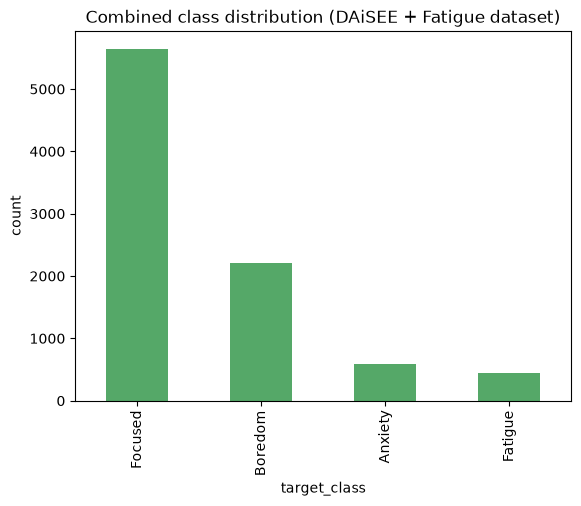

In [9]:
features_df["target_class"].value_counts().plot(kind="bar", color="#55A868")
plt.title("Combined class distribution (DAiSEE + Fatigue dataset)")
plt.ylabel("count")
plt.show()


## 6. Load features, check balance, split, and apply SMOTE

In [10]:
feature_cols = [c for c in features_df.columns if c not in ("ClipID", "target_class")]

# .to_numpy(dtype=...) avoids pandas' pyarrow-backed dtype issues with sklearn/imblearn
X = features_df[feature_cols].to_numpy(dtype=np.float64)
y = features_df["target_class"].astype(str).to_numpy()

print("Class distribution:")
print(pd.Series(y).value_counts())


Class distribution:
Focused    5647
Boredom    2212
Anxiety     591
Fatigue     442
Name: count, dtype: int64


In [11]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

print("Before SMOTE:", pd.Series(y_train).value_counts().to_dict())

smote = SMOTE(random_state=RANDOM_STATE)
X_train_bal, y_train_bal = smote.fit_resample(X_train, y_train)

print("After SMOTE:", pd.Series(y_train_bal).value_counts().to_dict())


Before SMOTE: {'Focused': 4517, 'Boredom': 1769, 'Anxiety': 473, 'Fatigue': 354}
After SMOTE: {'Focused': 4517, 'Anxiety': 4517, 'Boredom': 4517, 'Fatigue': 4517}


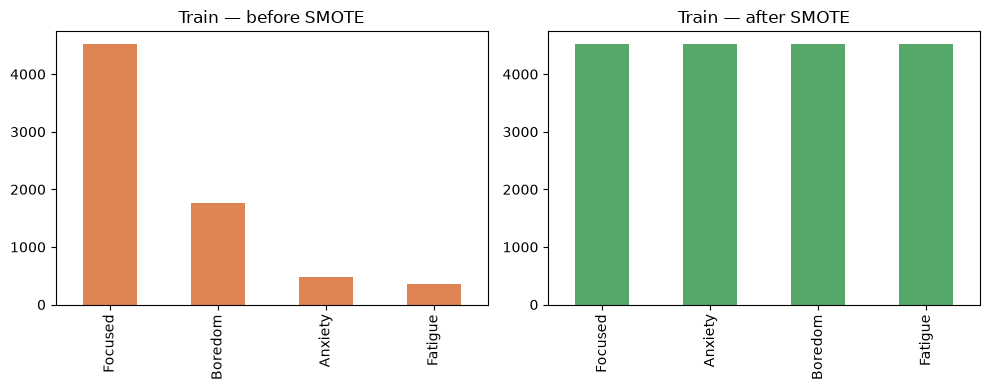

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
pd.Series(y_train).value_counts().plot(kind="bar", ax=axes[0], color="#DD8452", title="Train — before SMOTE")
pd.Series(y_train_bal).value_counts().plot(kind="bar", ax=axes[1], color="#55A868", title="Train — after SMOTE")
plt.tight_layout()
plt.show()


## 7. Train & compare XGBoost, Random Forest, and SVM

In [17]:
from sklearn.utils.class_weight import compute_sample_weight
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold, cross_val_score

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_bal)
X_test_scaled = scaler.transform(X_test)

# XGBoost requires integer-encoded labels, not strings
le = LabelEncoder()
y_train_bal_enc = le.fit_transform(y_train_bal)

# Per-sample weights so XGBoost also leans against the majority class
# (SMOTE already balanced the counts, but this reinforces it during training)
xgb_sample_weights = compute_sample_weight(class_weight="balanced", y=y_train_bal_enc)

# --- Light hyperparameter search for XGBoost (the usual strongest performer) ---
xgb_param_dist = {
    "n_estimators": [200, 300, 400, 500],
    "max_depth": [4, 6, 8, 10],
    "learning_rate": [0.03, 0.05, 0.1, 0.15],
    "subsample": [0.7, 0.85, 1.0],
    "colsample_bytree": [0.7, 0.85, 1.0],
}
xgb_search = RandomizedSearchCV(
    XGBClassifier(random_state=RANDOM_STATE, eval_metric="mlogloss", n_jobs=-1),
    param_distributions=xgb_param_dist,
    n_iter=15,               # tries 15 random combinations — increase for a more thorough search
    cv=3,
    scoring="accuracy",
    random_state=RANDOM_STATE,
    n_jobs=-1,
)
xgb_search.fit(X_train_bal, y_train_bal_enc, sample_weight=xgb_sample_weights)
print("Best XGBoost params:", xgb_search.best_params_)
print("Best XGBoost CV accuracy:", round(xgb_search.best_score_, 3))

models = {
    "Random Forest": RandomForestClassifier(
        n_estimators=300, max_depth=None, random_state=RANDOM_STATE,
        n_jobs=-1, class_weight="balanced",
    ),
    "XGBoost": xgb_search.best_estimator_,
    "SVM (RBF)": SVC(
        kernel="rbf", C=10, gamma="scale", random_state=RANDOM_STATE,
        class_weight="balanced",
    ),
}

results = {}
cv_splitter = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

for name, model in models.items():
    if name == "SVM (RBF)":
        model.fit(X_train_scaled, y_train_bal)
        preds = model.predict(X_test_scaled)
        cv_scores = cross_val_score(model, X_train_scaled, y_train_bal, cv=cv_splitter, n_jobs=-1)
    elif name == "XGBoost":
        # already fitted by the search above; still confirm test-set performance
        preds_enc = model.predict(X_test)
        preds = le.inverse_transform(preds_enc)
        cv_scores = cross_val_score(model, X_train_bal, y_train_bal_enc, cv=cv_splitter, n_jobs=-1)
    else:
        model.fit(X_train_bal, y_train_bal)
        preds = model.predict(X_test)
        cv_scores = cross_val_score(model, X_train_bal, y_train_bal, cv=cv_splitter, n_jobs=-1)

    acc = accuracy_score(y_test, preds)
    results[name] = {"model": model, "preds": preds, "accuracy": acc, "cv_mean": cv_scores.mean(), "cv_std": cv_scores.std()}
    print(f"\n=== {name} ===")
    print(f"Test accuracy: {acc:.3f}  |  5-fold CV accuracy: {cv_scores.mean():.3f} (+/- {cv_scores.std():.3f})")
    print(classification_report(y_test, preds))

Best XGBoost params: {'subsample': 1.0, 'n_estimators': 400, 'max_depth': 10, 'learning_rate': 0.15, 'colsample_bytree': 0.85}
Best XGBoost CV accuracy: 0.838

=== Random Forest ===
Test accuracy: 0.653  |  5-fold CV accuracy: 0.853 (+/- 0.006)
              precision    recall  f1-score   support

     Anxiety       0.15      0.14      0.15       118
     Boredom       0.49      0.46      0.47       443
     Fatigue       0.84      0.77      0.80        88
     Focused       0.75      0.77      0.76      1130

    accuracy                           0.65      1779
   macro avg       0.56      0.54      0.55      1779
weighted avg       0.65      0.65      0.65      1779


=== XGBoost ===
Test accuracy: 0.666  |  5-fold CV accuracy: 0.866 (+/- 0.006)
              precision    recall  f1-score   support

     Anxiety       0.20      0.10      0.13       118
     Boredom       0.49      0.37      0.42       443
     Fatigue       0.82      0.76      0.79        88
     Focused       0.73

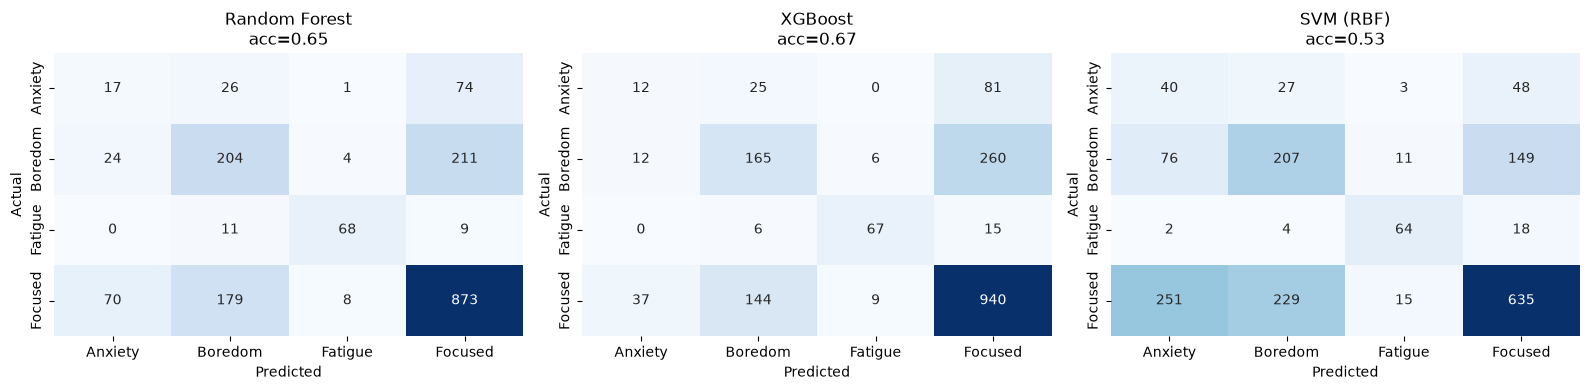

In [18]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
labels_order = sorted(pd.Series(y).unique())
for ax, (name, res) in zip(axes, results.items()):
    cm = confusion_matrix(y_test, res["preds"], labels=labels_order)
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=labels_order,
                yticklabels=labels_order, ax=ax, cbar=False)
    ax.set_title(f"{name}\nacc={res['accuracy']:.2f}")
    ax.set_xlabel("Predicted"); ax.set_ylabel("Actual")
plt.tight_layout()
plt.show()


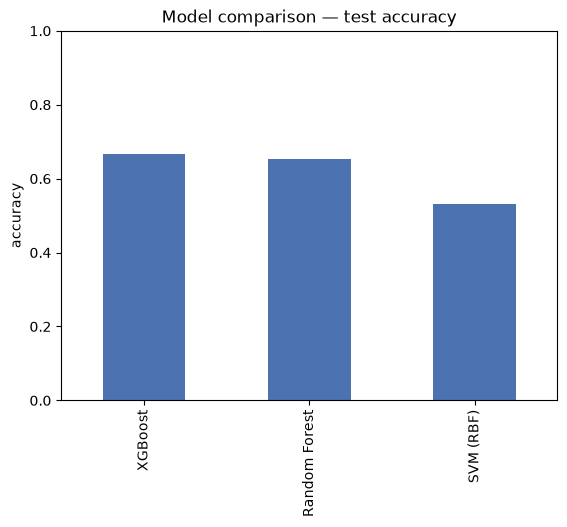

,accuracy
XGBoost,0.665542
Random Forest,0.653176
SVM (RBF),0.531759


In [19]:
acc_df = pd.DataFrame({name: [res["accuracy"]] for name, res in results.items()}).T
acc_df.columns = ["accuracy"]
acc_df.sort_values("accuracy", ascending=False).plot(kind="bar", legend=False, color="#4C72B0")
plt.title("Model comparison — test accuracy")
plt.ylabel("accuracy"); plt.ylim(0, 1)
plt.show()
acc_df.sort_values("accuracy", ascending=False)


## 8. Save the best model

In [20]:
best_name = acc_df["accuracy"].idxmax()
best_model = results[best_name]["model"]
print("Best model:", best_name)

joblib.dump(best_model, os.path.join(MODEL_DIR, f"best_model_{best_name.replace(' ', '_')}.joblib"))
joblib.dump(scaler, os.path.join(MODEL_DIR, "scaler.joblib"))
if best_name == "XGBoost":
    joblib.dump(le, os.path.join(MODEL_DIR, "label_encoder.joblib"))
print("Saved to", MODEL_DIR)


Best model: XGBoost
Saved to ./backend/models/focus


## Notes for your report / viva

- The Fatigue class now has genuine, purpose-built labels from a dedicated drowsiness dataset (UTA-RLDD-based), not just DAiSEE's weak proxy — worth highlighting as a deliberate methodology improvement.
- SMOTE is applied only to the training set — this avoids leaking synthetic samples into evaluation.
- `X = features_df[feature_cols].to_numpy(dtype=np.float64)` and `y = ...astype(str).to_numpy()` are used instead of `.values` to sidestep a pandas pyarrow-backed dtype issue that breaks sklearn/imblearn on some environments.
- XGBoost needs integer-encoded labels (`LabelEncoder`), while Random Forest and SVM accept string labels directly — this is handled per-model in the training loop.
